# Baseline TF-IDF + Logistic Regression

## Objetivo del notebook

Este notebook tiene como objetivo entrenar el primer modelo baseline para la clasificación de sentimiento en noticias financieras.

El modelo baseline utiliza una estrategia clásica de NLP:

1. **TF-IDF** para convertir texto en vectores numéricos.
2. **Logistic Regression** para clasificar cada texto en una de tres clases: negative, neutral o positive.

Este modelo servirá como punto de comparación contra modelos más avanzados basados en embeddings de Hugging Face y PyTorch.

---



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline

In [2]:
PATH = Path("../data/processed/financial_phrasebank_processed.csv")
df = pd.read_csv(PATH, encoding="utf-8")
df.head()

,text,label,label_id
0,"According to Gran , the company has no plans t...",neutral,1
1,Technopolis plans to develop in stages an area...,neutral,1
2,The international electronic industry company ...,negative,0
3,With the new production plant the company woul...,positive,2
4,According to the company 's updated strategy f...,positive,2


## 1. Separación entre variables de entrada y variable objetivo

Para entrenar el modelo, se separan los datos en:

- `X`: textos financieros.
- `y`: etiquetas numéricas de sentimiento.

El modelo recibe el texto y aprende a predecir la clase correspondiente.

Codificación utilizada:

| label | label ID |
|---|---:|
| negative | 0 |
| neutral | 1 |
| positive | 2 |

In [5]:
class_distribution = (
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

class_distribution

label
neutral     59.36
positive    28.15
negative    12.48
Name: proportion, dtype: float64

In [6]:
X = df[["text"]]
y = df["label_id"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (4838, 1)
y shape: (4838,)


## 2. División train/test

El dataset se dividirá en conjuntos de entrenamiento y prueba.

El conjunto de entrenamiento se usa para ajustar el modelo.

El conjunto de prueba se reserva para evaluar qué tan bien generaliza el modelo a textos no vistos.

Como se trata de clasificación multiclase y puede existir desbalance entre clases, la división debe hacerse de forma estratificada. Esto significa que train y test conservarán proporciones similares de negative, neutral y positive.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (3870, 1)
X_test: (968, 1)
y_train: (3870,)
y_test: (968,)


In [9]:
train_distribution = y_train.value_counts(normalize=True).sort_index().mul(100).round(2)
test_distribution = y_test.value_counts(normalize=True).sort_index().mul(100).round(2)

split_distribution = pd.DataFrame(
    {
        "train_%": train_distribution,
        "test_%": test_distribution,
    }
)

split_distribution

,train_%,test_%
label_id,,
0,12.48,12.5
1,59.35,59.4
2,28.17,28.1


## 3. Vectorización con TF-IDF

Los modelos de Machine Learning no entienden texto directamente.

Por eso, cada texto debe transformarse en una representación numérica.

TF-IDF significa **Term Frequency - Inverse Document Frequency**.

La idea general es asignar mayor peso a palabras que son importantes dentro de un texto, pero que no aparecen en todos los textos.

Por ejemplo, palabras como `profit`, `loss`, `declined` o `growth` pueden ser más útiles para clasificar sentimiento financiero que palabras muy comunes como `the`, `company` o `said`.



In [12]:
text_preprocessor = ColumnTransformer(
    transformers=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words=None,
                ngram_range=(1, 1),
                max_features=5000,
            ),
            "text",
        )
    ],
    remainder="drop",
)

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", text_preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

baseline_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tfidf', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

## 4. Pipeline de scikit-learn

El baseline se implementará como un pipeline de scikit-learn.

Esto es importante porque garantiza que el mismo flujo usado durante entrenamiento también se use durante inferencia.

El pipeline incluye:

1. Selección de la columna de texto.
2. Transformación del texto con TF-IDF.
3. Clasificación con Logistic Regression.

Esto evita tener pasos manuales separados que puedan olvidarse al guardar o cargar el modelo.


In [13]:
baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tfidf', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [14]:
y_pred_baseline = baseline_pipeline.predict(X_test)

y_pred_baseline[:10]

array([1, 1, 1, 2, 2, 1, 1, 0, 2, 1])

In [15]:
y_proba_baseline = baseline_pipeline.predict_proba(X_test)

y_proba_baseline[:5]

array([[0.04245606, 0.84447994, 0.113064  ],
       [0.0754035 , 0.60597887, 0.31861763],
       [0.05582384, 0.82554694, 0.11862922],
       [0.21009673, 0.38268056, 0.40722271],
       [0.06854468, 0.0529669 , 0.87848842]])

## 5. Evaluación inicial del baseline

Después de entrenar el modelo, se evaluará con métricas de clasificación.

Las métricas principales serán:

- accuracy,
- precision,
- recall,
- F1-score,
- macro F1,
- matriz de confusión.

La métrica macro F1 es especialmente importante si existe desbalance de clases, porque calcula el desempeño promedio dando el mismo peso a cada clase.

In [16]:
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_macro_f1 = f1_score(y_test, y_pred_baseline, average="macro")
baseline_weighted_f1 = f1_score(y_test, y_pred_baseline, average="weighted")

print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"Macro F1: {baseline_macro_f1:.4f}")
print(f"Weighted F1: {baseline_weighted_f1:.4f}")

Accuracy: 0.7583
Macro F1: 0.6834
Weighted F1: 0.7429


In [17]:
target_names = ["negative", "neutral", "positive"]

print(
    classification_report(
        y_test,
        y_pred_baseline,
        target_names=target_names,
    )
)

              precision    recall  f1-score   support

    negative       0.81      0.49      0.61       121
     neutral       0.76      0.93      0.84       575
    positive       0.74      0.51      0.61       272

    accuracy                           0.76       968
   macro avg       0.77      0.64      0.68       968
weighted avg       0.76      0.76      0.74       968



## 6. Matriz de confusión

La matriz de confusión permite analizar los errores del modelo.

Muestra cuántas observaciones reales de cada clase fueron clasificadas como negative, neutral o positive.

Esto permite responder preguntas como:

- ¿El modelo confunde negative con neutral?
- ¿Predice demasiados textos como neutral?
- ¿Qué clase es más difícil de identificar?

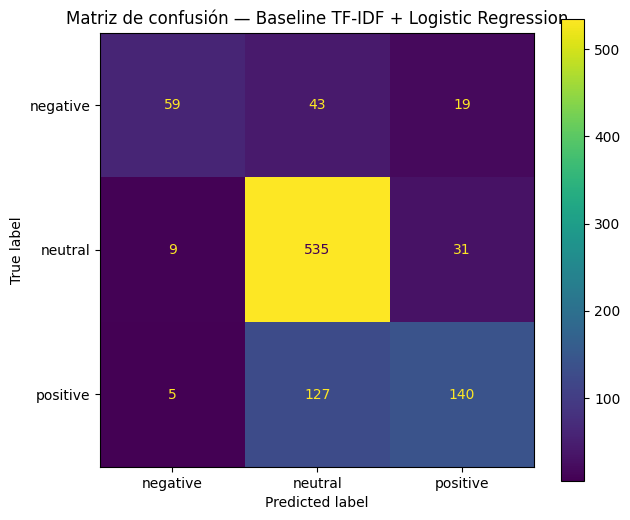

In [18]:
cm = confusion_matrix(y_test, y_pred_baseline)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names,
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")

plt.title("Matriz de confusión — Baseline TF-IDF + Logistic Regression")
plt.show()

## 8. Búsqueda de hiperparámetros

Una vez entrenado el baseline inicial, se probarán distintas configuraciones mediante GridSearchCV.

Algunos hiperparámetros relevantes son:

- `ngram_range`: si el modelo usa palabras individuales o combinaciones de palabras.
- `max_features`: número máximo de términos considerados por TF-IDF.
- `C`: nivel de regularización de Logistic Regression.
- `class_weight`: si se ajusta el peso de clases desbalanceadas.

El objetivo no es probar infinitas combinaciones, sino encontrar una configuración razonable y documentar qué se intentó.

In [19]:
param_grid = {
    "preprocessor__tfidf__ngram_range": [(1, 1), (1, 2)],
    "preprocessor__tfidf__max_features": [3000, 5000, 10000],
    "classifier__C": [0.1, 1.0, 3.0, 10.0],
    "classifier__class_weight": [None, "balanced"],
}

In [20]:
grid_search = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2,
)

In [21]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1.0, ...], 'classifier__class_weight': [None, 'balanced'], 'preprocessor__tfidf__max_features': [3000, 5000, ...], 'preprocessor__tfidf__ngram_range': [(1, ...), (1, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the hi

In [22]:
print("Mejores hiperparámetros:")
print(grid_search.best_params_)

print("\nMejor score de validación cruzada:")
print(grid_search.best_score_)

Mejores hiperparámetros:
{'classifier__C': 3.0, 'classifier__class_weight': 'balanced', 'preprocessor__tfidf__max_features': 10000, 'preprocessor__tfidf__ngram_range': (1, 2)}

Mejor score de validación cruzada:
0.7244880736336333


## 10. Comparación entre baseline inicial y modelo optimizado

Al final del notebook se comparará:

1. Modelo baseline inicial.
2. Modelo optimizado con GridSearchCV.

La comparación incluirá métricas como accuracy y macro F1.

Esta comparación ayudará a decidir qué configuración llevar posteriormente al código de producción dentro de `src/`.

In [23]:
best_tfidf_model = grid_search.best_estimator_

y_pred_best = best_tfidf_model.predict(X_test)
y_proba_best = best_tfidf_model.predict_proba(X_test)

In [24]:
best_accuracy = accuracy_score(y_test, y_pred_best)
best_macro_f1 = f1_score(y_test, y_pred_best, average="macro")
best_weighted_f1 = f1_score(y_test, y_pred_best, average="weighted")

print(f"Accuracy: {best_accuracy:.4f}")
print(f"Macro F1: {best_macro_f1:.4f}")
print(f"Weighted F1: {best_weighted_f1:.4f}")

Accuracy: 0.7562
Macro F1: 0.7200
Weighted F1: 0.7555


In [25]:
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=target_names,
    )
)

              precision    recall  f1-score   support

    negative       0.69      0.69      0.69       121
     neutral       0.81      0.82      0.82       575
    positive       0.67      0.65      0.66       272

    accuracy                           0.76       968
   macro avg       0.72      0.72      0.72       968
weighted avg       0.75      0.76      0.76       968



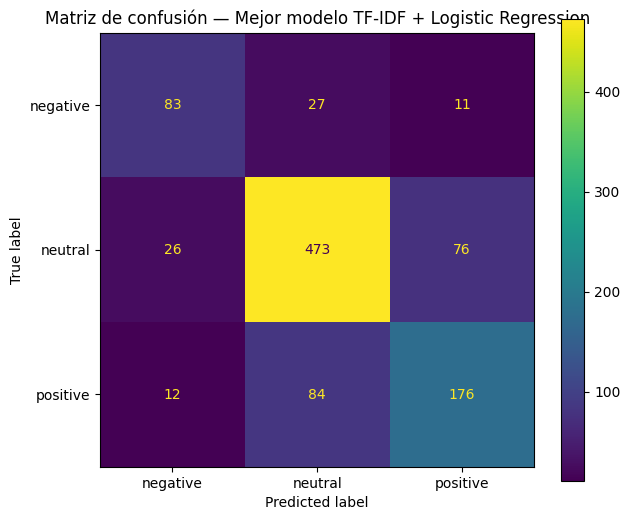

In [26]:
cm_best = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=target_names,
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")

plt.title("Matriz de confusión — Mejor modelo TF-IDF + Logistic Regression")
plt.show()

In [27]:
comparison_results = pd.DataFrame(
    {
        "model": [
            "Baseline TF-IDF + LogisticRegression",
            "Optimized TF-IDF + LogisticRegression",
        ],
        "accuracy": [
            baseline_accuracy,
            best_accuracy,
        ],
        "macro_f1": [
            baseline_macro_f1,
            best_macro_f1,
        ],
        "weighted_f1": [
            baseline_weighted_f1,
            best_weighted_f1,
        ],
    }
)

comparison_results

,model,accuracy,macro_f1,weighted_f1
0,Baseline TF-IDF + LogisticRegression,0.758264,0.683415,0.742883
1,Optimized TF-IDF + LogisticRegression,0.756198,0.720038,0.755463


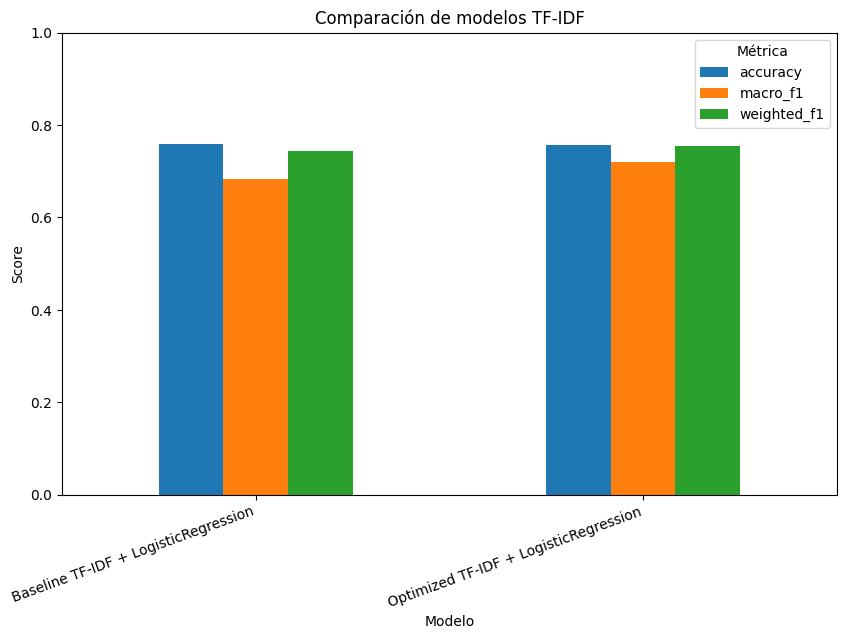

In [28]:
comparison_plot = comparison_results.set_index("model")[["accuracy", "macro_f1", "weighted_f1"]]

comparison_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Comparación de modelos TF-IDF")
plt.xlabel("Modelo")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Métrica")
plt.show()